# EDA and first step of feature selection

In [54]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [55]:
X_train = pd.read_csv("/Users/ola/projects/cost-sensitive-marketing/data/x_train.txt", sep = " ")
y_train = pd.read_csv("/Users/ola/projects/cost-sensitive-marketing/data/y_train.txt", sep = " ")
n_old, p_old = X_train.shape

X_train = X_train.T.drop_duplicates().T
X_train.drop_duplicates(inplace=True)
n, p = X_train.shape
# duplicate columns: V175 = V32, V416 = V160

In [56]:
print(f"Shape: n = {n}, p = {p}")
print(f"Class 1: {np.mean(y_train) * 100:0.2f}%")
print(f"Column types: {np.unique(X_train.dtypes)}")
print(f"Missing data: {np.sum(np.sum(X_train.isna(), axis=1), axis=0)}")
print(f"Column duplicates: {p_old - p}, row duplicates: {n_old - n}")

Shape: n = 5000, p = 498
Class 1: 49.76%
Column types: [dtype('float64')]
Missing data: 0
Column duplicates: 2, row duplicates: 0


In [57]:
X_train.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V491,V492,V493,V494,V495,V496,V497,V498,V499,V500
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.500233,0.500273,10.048039,0.495947,0.025057,0.496769,0.498385,0.498027,0.493844,-0.022705,...,-0.005252,0.503225,0.500664,0.005485,9.983796,0.014929,0.495957,9.953891,-0.017337,0.497873
std,0.286156,0.285742,4.582863,0.286356,2.480097,0.292497,0.290257,0.291401,0.289450,0.993465,...,1.000026,0.286948,0.291534,1.004822,4.487236,0.991845,0.290911,4.435534,0.990030,0.288636
min,0.000195,0.000107,0.958113,0.000026,-8.803497,0.000116,0.000075,0.000060,0.000095,-3.693892,...,-3.750717,0.000151,0.000105,-3.587849,0.986320,-3.358077,0.000163,0.940390,-3.381385,0.000106
25%,0.254151,0.247001,6.771772,0.248746,-1.613801,0.241448,0.247769,0.240210,0.242509,-0.712855,...,-0.665776,0.256773,0.245910,-0.676383,6.716957,-0.658023,0.243473,6.685453,-0.675339,0.250572
50%,0.506632,0.502785,9.310201,0.500593,0.022467,0.494284,0.498828,0.498829,0.488783,-0.019341,...,0.001532,0.504650,0.499564,0.009176,9.370211,0.016059,0.500924,9.286676,-0.012790,0.497029
75%,0.743107,0.746211,12.658089,0.741587,1.693679,0.756912,0.748557,0.744075,0.748062,0.651148,...,0.646321,0.748965,0.756052,0.683569,12.524212,0.696753,0.747700,12.458401,0.662880,0.746191
max,0.999599,0.999994,33.537836,0.999796,9.441396,0.999849,0.999791,0.999605,0.999690,3.145788,...,3.861070,0.999976,0.999963,3.789411,39.996344,4.547909,0.999711,30.002210,3.460326,0.999529


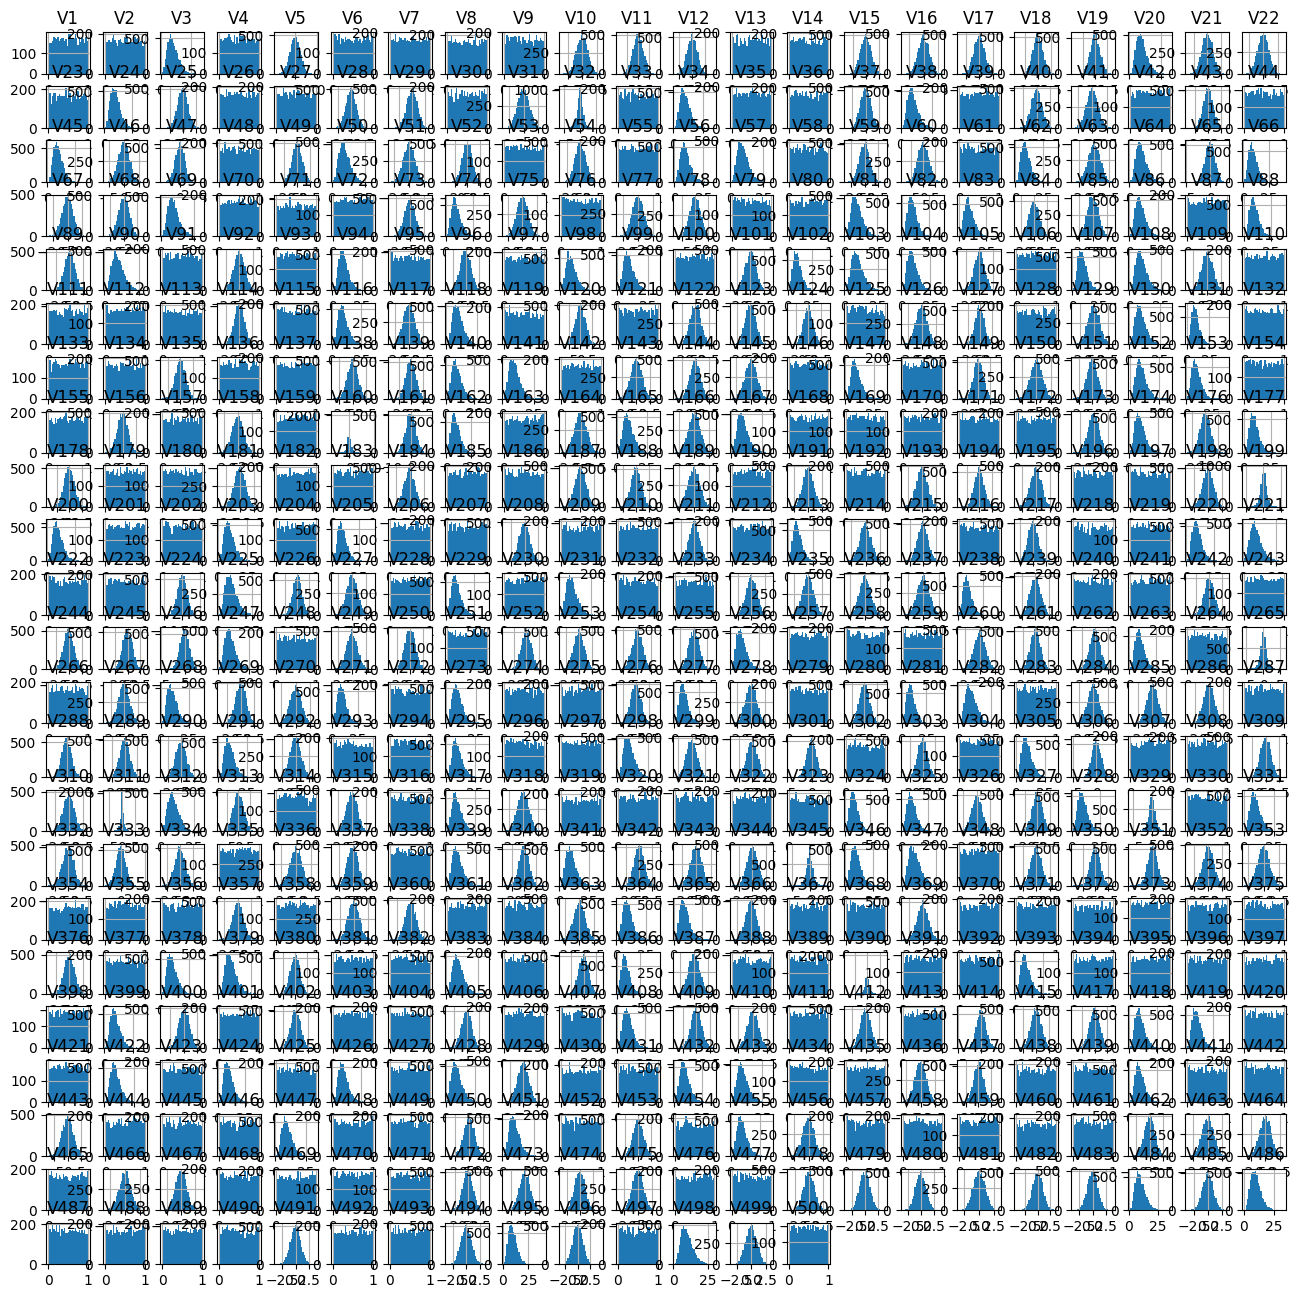

In [58]:
X_train.hist(figsize=(16, 16), bins=30)
plt.show()
# all predictors are look like either normal, gamma (skewed to the right) or uniform distribution ?
# hard to notice any "anomalities"
# no constant features

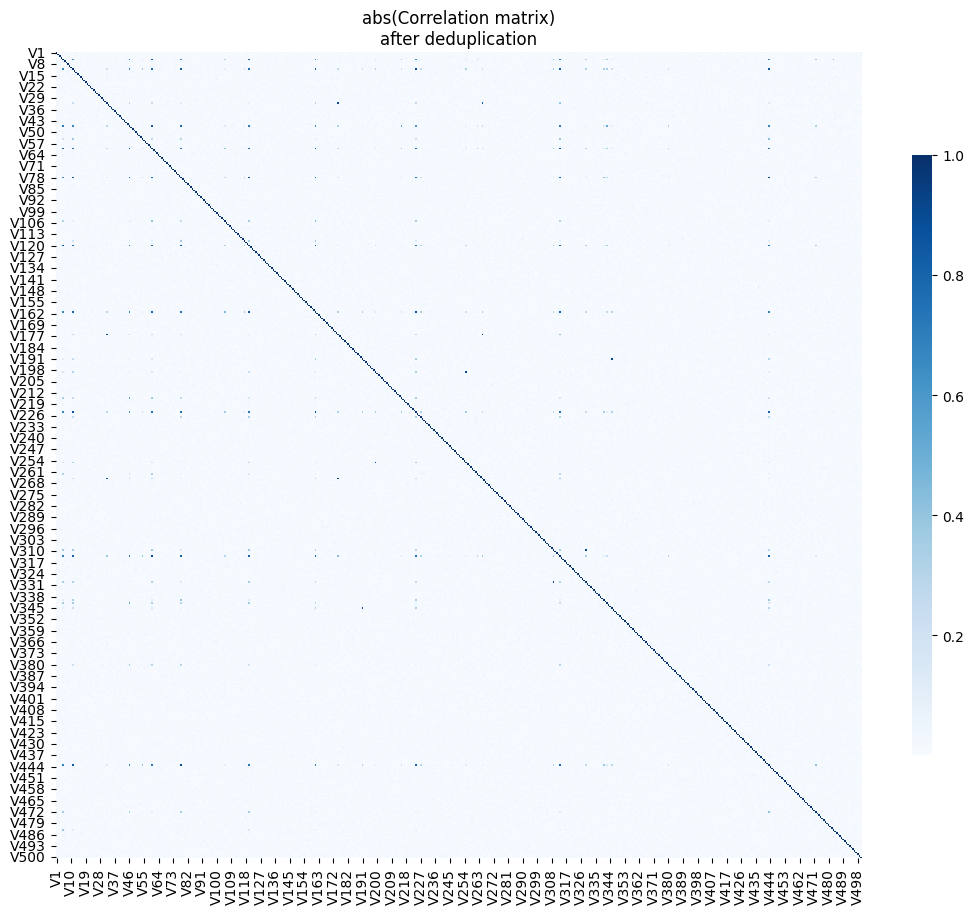

In [59]:
corr_matrix = np.abs(X_train.corr())
fig, ax = plt.subplots(figsize=(13, 13))
sns.heatmap(
    corr_matrix,
    square=True,
    cmap="Blues",
    cbar_kws={"shrink": 0.6, "aspect": 30})
plt.title("abs(Correlation matrix)\nafter deduplication")
plt.show()

# intersting grid-like pattern

## First step of feature selection

In [ ]:
# columns with correlation > 0.8
corr_matrix = np.abs(X_train.corr())
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

cols = []
high_corr_pairs = []
for row in upper.index:
    for col in upper.columns:
        if upper.loc[row, col] > 0.8:
            high_corr_pairs.append((col, row, upper.loc[row, col]))
            cols.append(col)
            cols.append(row)
cols = np.unique(cols)

for elem in high_corr_pairs:
    print(elem)

# VERY interesting results!
# these variables create 5 clusters

('V60', 'V5', np.float64(0.8213618338158666))
('V78', 'V11', np.float64(0.8076392656171207))
('V224', 'V11', np.float64(0.8807696253441699))
('V313', 'V11', np.float64(0.8097464730132935))
('V443', 'V11', np.float64(0.8447086696596476))
('V176', 'V32', np.float64(0.9152183464604331))
('V265', 'V32', np.float64(0.8357556535717495))
('V60', 'V46', np.float64(0.8285751892361178))
('V313', 'V60', np.float64(0.8851603803348861))
('V120', 'V78', np.float64(0.8352581816575597))
('V443', 'V78', np.float64(0.8825319202119688))
('V161', 'V120', np.float64(0.84175947598537))
('V224', 'V161', np.float64(0.8710001292081314))
('V313', 'V161', np.float64(0.8039000893985798))
('V265', 'V176', np.float64(0.9121312557222008))
('V345', 'V191', np.float64(0.912227974718394))
('V255', 'V199', np.float64(0.9103210476984752))
('V443', 'V224', np.float64(0.800273796436642))
('V329', 'V309', np.float64(0.9120051194651927))


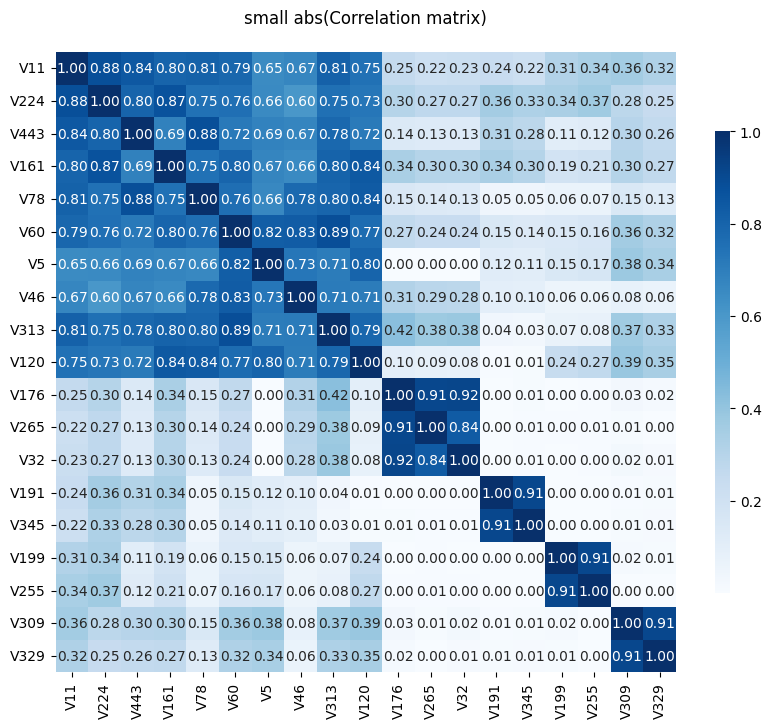

In [ ]:
c = [
    "V11",
    "V224",
    "V443",
    "V161",
    "V78",
    "V60",
    "V5",
    "V46",
    "V313",
    "V120",
    "V176",
    "V265",
    "V32",
    "V191",
    "V345",
    "V199",
    "V255",
    "V309",
    "V329",
]
a = corr_matrix.loc[c, c]
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    a,
    annot=True,
    fmt=".2f",
    square=True,
    # vmin=0.6,
    cmap="Blues",
    cbar_kws={"shrink": 0.6, "aspect": 30},
)
plt.title("small abs(Correlation matrix)\n")
plt.show()

# here we can see clearly the 5 groups
# for the 4 small grous we will keep one variable and then we will think what to do with the big group

In [ ]:
# aggregated results of 4 differnt approaches to evaluating feature importnance (anova f statistic, auc per variable, mutual inforamtion, boruta)
df = pd.read_csv("/Users/ola/projects/cost-sensitive-marketing/src/feature_selection/feature_importance_rank.csv")

# rank of the highly correlated varaivbles
df[df["variable"].isin(cols)][["variable", "overall_rank"]]

,variable,overall_rank
0,V11,1
1,V176,2
2,V255,3
3,V313,4
4,V265,5
5,V191,6
6,V224,7
7,V161,8
8,V443,9
9,V5,10


1. big group <br>
    maybe v11 (rank 1), v313 (rank 4) or v224 (rank 7) - test during cv <br>
1. group 176, 265, 32 <br> 
    ranks: 2, 5, 19<br> 
    keep: 176<br>
2. group 191, 345<br>
    ranks: 6, 14<br>
    keep: 191

3. group 199, 255<br>
    ranks: 16, 3<br>
    keep: 255

4. group 309, 329<br>
    ranks: 12, 25<br>
    keep: 309

In [ ]:
keep = ['V11', 'V176', 'V191', 'V255', 'V309']
drop = list(set(cols) - set(keep))
top40 = list(df["variable"].head(40))
selected = list(set(top40) - set(drop))
print(f"{len(selected)} predictors selected for further examination and model evaluation:")
print(selected)

27 predictors selected fot further examination and model evaluation:
['V449', 'V306', 'V11', 'V394', 'V356', 'V256', 'V55', 'V309', 'V34', 'V390', 'V3', 'V321', 'V94', 'V477', 'V221', 'V6', 'V444', 'V377', 'V262', 'V175', 'V191', 'V393', 'V255', 'V176', 'V212', 'V464', 'V366']
